# Step 3: Immune Density Visualization
**Purpose:** Combine the per sample immune density CSVs from step 2 into a single table and make boxplots comparing immune cell infiltration across genotypes (final visual output of this pipeline)

## What this notebook does

1. **Configuration + setup:** Define input and output directories, the genotype display order, color palette, and which immune markers to plot
2. **Data aggregation:** Find every `*immune_densities*.csv` file in the data directory (one per sample from step 2), stack them into one combined dataframe (one row per ROI), and save a merged csv for reference
3. **Validation:** Confirm expected density columns and genotypes are actually present in the combined data, warn the user before any plots are generated if any missing
4. **Plot generation:** For each immune marker, build a layered figure containing: a colored boxplot per genotype, individual ROI points, and mean +- SD error bars 

## Inputs

* `<sample_id>_immune_densities.csv`: immune density tables from step 2 (one per sample)

## Outputs

* `combined_immune.csv`: single merged table with all ROIs from all samples
* `<MARKER>_density.png`: one boxplot per immune marker 

## Requirements

* Python 3.10 environment with: pandas, numpy, matplotlib
* No manual steps required for this part!

In [2]:
# Import dependencies
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns


# Hide minor warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
# ‼️UPDATE‼️ this cell when doing a new sample 

# First set your working directory (this is the analysis directory we created in Step 1)
working_dir = Path('/Users/elizabethxiu/Downloads/KS_2/analysis') # Please update root folder containing all the samples

DATA_DIR = Path(f'{working_dir}/immune') # folder containing per sample immune densities CSVs (step 2 output)

SAVE_DIR = Path(f'{working_dir}/plots') # output folder to save the plots we create

GENOTYPE_ORDER = ["KO"] # genotype display order from left to right on x axis

GENOTYPE_COLORS = { # colors for each genotype (must match names above exactly)
    "KO": "#d62728"
}


   
SAVE_DPI = 300 # dots per inch, 300 is the publication standard but 150 fine for internal review

# Confirm the configuration 
print(f"Data directory: {DATA_DIR}")
print(f"Save directory: {SAVE_DIR}")
print(f"Genotypes: {GENOTYPE_ORDER}")


Data directory: /Users/elizabethxiu/Downloads/KS_2/analysis/immune
Save directory: /Users/elizabethxiu/Downloads/KS_2/analysis/plots
Genotypes: ['KO']


In [8]:
## Find all per sample immune density CSVs 
# Skip macOS AppleDouble files (they end in ._filename); these show up when the drive was accessed on a mac, but they're not actually CSVs!
    
csv_files = sorted(
    f for f in DATA_DIR.glob("*immune_densities*.csv") # looks for csv files that contain "immune_densities"
    if not f.name.startswith("._")                     # sorted alphabetically
    )  

print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print(f" - {f.name}") # gives you filename without the full path

# This is like a checkpoint -- stop early with a clear message if no files could be found
if len(csv_files) == 0:
    raise FileNotFoundError( # trigger an exception -- stop running if there are no files
        f"No correct files found in:\n{DATA_DIR}\n"
        "Check that your DATA_DIR is correct and/or that step 2 ran correctly.") 

# Stack all of the CSVs into 1 dataframe 
df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True) # reset the row numbering so rows don't repeat within each file

print(f"\nCombined table has {df.shape[0]} rows and {df.shape[1]} columns")

# Save the combined CSV for reference and use later on
combined_path = DATA_DIR / "combined_immune.csv"
df.to_csv(combined_path, index=False)
print(f"Combined CSV has been saved to {combined_path}")

# Define the immune markers to plot -- these have to match column names in the combined CSV exactly
DENSITY_COLS = [c for c in df.columns if c.endswith('_cells_per_mm2')]


# Check the genotypes that were found vs expected 
found_genotypes = df["Genotype"].unique().tolist() # get all the distinct values in genotype column and convert to a list
missing_genos = [g for g in GENOTYPE_ORDER if g not in found_genotypes]
if missing_genos:
    print(f"\nWarning, these genotypes are missing from the data: {missing_genos}")
else:
    print("All expected genotypes are present!")

# Preview the first few rows 
df.head()



Found 2 CSV file(s):
 - 40_ST_KO_immune_densities.csv
 - 41_ST_KO_immune_densities.csv

Combined table has 5 rows and 35 columns
Combined CSV has been saved to /Users/elizabethxiu/Downloads/KS_2/analysis/immune/combined_immune.csv
All expected genotypes are present!


,Sample,Genotype,ROI,Total_Cells,Area_mm2,neutrophils_count,neutrophils_fraction,neutrophils_cells_per_mm2,tumor cells_count,tumor cells_fraction,...,epithilial cells_cells_per_mm2,dendritic cells_count,dendritic cells_fraction,dendritic cells_cells_per_mm2,cd8 t cells_count,cd8 t cells_fraction,cd8 t cells_cells_per_mm2,cd4 t cells_count,cd4 t cells_fraction,cd4 t cells_cells_per_mm2
0,40_ST_KO,KO,Tumor,49237,5.516132,0,0.000000,0.000000,17219,0.349717,...,221.169465,6961,0.141377,1261.934957,8,0.000162,1.450292,235,0.004773,42.602315
1,40_ST_KO,KO,Spleen,951422,46.873268,39,0.000041,0.832031,569,0.000598,...,1.344050,191494,0.201271,4085.356256,39015,0.041007,832.350749,407413,0.428215,8691.798429
2,41_ST_KO,KO,Spleen,909485,45.429996,200,0.000220,4.402378,169,0.000186,...,3.147700,131436,0.144517,2893.154548,29967,0.032949,659.630256,21197,0.023307,466.585996
3,41_ST_KO,KO,Tumor1,85849,14.004221,543,0.006325,38.774025,12697,0.147899,...,995.414192,16024,0.186653,1144.226471,29,0.000338,2.070804,95,0.001107,6.783669
4,41_ST_KO,KO,Tumor2,207921,23.785391,33,0.000159,1.387406,17511,0.084219,...,152.993071,5816,0.027972,244.519841,5,0.000024,0.210213,40,0.000192,1.681705


## Plot immune densities
**Purpose:** Loop over each marker in `DENSITY_COLS` and make 1 figure per marker, layering 3 views of the data on the same axes: boxplot (median + IQR), jittered scatter (every individual ROI), and mean +- SD error bars. Each figure is saved as a 300 dpi PNG image to `SAVE_DIR` file path

In [51]:
# Create the output directory if it doesn't exist 
os.makedirs(SAVE_DIR, exist_ok=True) # move on if already exists

# Set a random seed so jitter is identical across runs -- without this the scatter positions would change every run
# This would make each figure version look a little different even when the data didn't change
np.random.seed(42)

# Set this to True to use log y-axis, useful when densities span orders of magnitude across genotypes
USE_LOG_SCALE = False  # ‼️UPDATE‼️ THIS if needed

# Global font/style settings 
plt.rcParams.update({
    "font.size":       11,
    "axes.labelsize":  12,
    "axes.titlesize":  13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth":  1.2,
})

# ------------------------------------------------------------------------------------
# MAIN PLOTTING LOOP
# This iterates through each immune marker (CD8, CD4, etc) defined in the configuration
# and makes 1 boxplot figure per marker, saved as a PNG
# ------------------------------------------------------------------------------------

for col in DENSITY_COLS:  # iterate through each marker column, like "cd8_cells_per_mm2"

    # Step 1-- Safety check 
    if col not in df.columns: # Again, if column is missing from the dataframe, skip it and jump to the next marker
        print(f"SKIP {col} —- column not found in the data")
        continue                                        

    # Step 2-- Pull data for this marker, split by each genotype. End up with a list of arrays, one per genotype
    data = [ # select specific rows + columns; use boolean mask to pull all rows of a genotype, then marker column for those rows
        df.loc[df["Genotype"] == g, col].dropna().values for g in GENOTYPE_ORDER ]
                                                         # drop ROIs where marker wasn't measured
                                                         # convert pandas series to plain numpy array
                                                         # repeat for each genotype in display order
                                             
    

    # Step 3-- Print per marker sample counts 
    counts_str = ", ".join( # join strings together separated by commas
        f"{g}: n={len(d)}"  # format like "Genotype : number of ROIs it corresponds to"
        for g, d in zip(GENOTYPE_ORDER, data) # pair each genotype name with its array
    )
    print(f"{col} | {counts_str}") 

    # Step 4-- Set the x axis positions for each genotype group 
    x = np.arange(1, len(GENOTYPE_ORDER) + 1) # → generate a sequence of numbers for how many genotypes there are

    # Step 5-- Create the figure and axes 
    fig, ax = plt.subplots(figsize=(5.2, 4.5)) # fig is the canvas (for saving), and ax is the actual plot area in inches

    # Step 6-- Draw the boxplot 
    # NOTE: Normally the upper whisker extends from Q3 up to the highest data point that is still BELOW the outlier fence (Q3+1.5*IQR)
    # BUT: if the highest non-outlier is itself below Q3, the whisker
    #   collapses, and the upper cap gets drawn AT Q3 (right on top of the
    #   box edge) -- making it visually invisible.
    # - The same mirror rule applies to the lower whisker with Q1.
    box = ax.boxplot( # returns dict with references to the pieces of the boxplot
        data, # the list of arrays, one box drawn per array
        positions=x, # where on x-axis each box sits
        widths=0.55, # box width in x-axis units
        patch_artist=True, # required to color the box faces (otherwise boxes are just outlines)
        showfliers=False, # hide the default outlier dots, going to draw all points ourselves below
        medianprops=dict(color="black", linewidth=1.5),  # styling for the median line
        boxprops=dict(linewidth=1.2),  # styling for the box outline
        whiskerprops=dict(linewidth=1.0), # styling for the whisker lines
        capprops=dict(linewidth=1.0)# styling for the whisker end caps
    )
    

    # Step 7-- Color each box by genotype 
    for patch, g in zip(box["boxes"], GENOTYPE_ORDER):  # pair each box with its genotype name (same order)
        patch.set_facecolor(GENOTYPE_COLORS.get(g, "lightgray"))  # look up color, fall back to lightgray if missing
        patch.set_edgecolor("black")  # black border for contrast
        patch.set_alpha(0.75) # 75% opaque so scatter dots show through


    # Step 8-- Overlay individual ROI points (jittered) 
    for i, y in enumerate(data): # loop through a list giving you position index and the array of densities for that genotype
        if len(y) == 0:  # skip if this genotype has no data for this marker
            continue
        jitter = (np.random.rand(len(y)) - 0.5) * 0.20  # random horizontal wobble within a range --
                                                        # generate len(y) random nums between 0 and 1, - 0.5 and then * 0.20 to shrink the range
                                                        # now nums span -0.10 to 0.10, those are the "wobble values"
        ax.scatter( # draws the individual dots, one dot = one point (ROI); map each x-coord entry to y-coord entry 
            np.full(len(y), x[i]) + jitter,  # x coords: make an array of len(y) entries where every entry is value x[i] (the x-position) 
                                             # then adjust by the jitter ("wobble values")
            y,  # y coords: the density values themselves (the array of all of that genotype's ROI densities)
            color="black",
            s=18, # dot size (points^2)
            alpha=1.0, 
            zorder=4, # dots sit ON boxes
        )

    # Step 9-- Overlay mean and SD error bars 
    # NOTE: if ecolor (color of error bars) conflicts with a genotype box color in GENOTYPE_COLORS, change ecolor below 
    
    means = [np.mean(y) if len(y) > 0 else np.nan for y in data]  # NaN for empty genotypes so matplotlib just skips 
    stds  = [np.std(y)  if len(y) > 0 else np.nan for y in data]  # one mean + SD density value per genotype
    ax.errorbar( 
        x, means,
        yerr=stds, # vertical error bar length is +-1 SD
        fmt="D",  # distinctive diamond marker for the mean
        color="black",
        markersize=8,
        markeredgecolor="white",   # white border so it pops against the box
        markeredgewidth=1.5,  
        ecolor="#1f77b4",  # color of the SD lines + caps (blue here)
        elinewidth=1.5,  # thickness of vertical SD lines
        capsize=4, # short horizontal caps at error bar ends
        linewidth=1.2,
        zorder=3, # draw ON scatter dots
    )

    # Step 10-- Build clean marker name for title 
    marker = col.replace("_cells_per_mm2", "").upper()  # Example: "cd8_cells_per_mm2" becomes "CD8"


    # Step 11-- Axis labels, ticks, + title 
    ax.set_xticks(x)  # put a tick at each genotype position 
    ax.set_xticklabels(GENOTYPE_ORDER, rotation=0)  # replace numbers with genotype names
    ax.set_xlabel("Genotype")
    ax.set_ylabel("Cells per mm^2")
    ax.set_title(f"{marker} cell density")

    if USE_LOG_SCALE: # optional log y-axis (set in config cell)
        ax.set_yscale("log")

    # Step 12-- Visual edits 
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)  # lightly dashed horizontal grid
    ax.set_axisbelow(True) # grid sits behind boxes/dots, not on top
    ax.spines["top"].set_visible(False)  # remove top frame line
    ax.spines["right"].set_visible(False) # remove right frame line
    plt.tight_layout()  # auto adjust margins so labels don't get cut off weirdly

    # Step 13-- Save the figure 
    try:
        filename = f"{marker}_density.png"    
        save_path = SAVE_DIR / filename # full output path using pathlib
        plt.savefig(save_path, dpi=SAVE_DPI, bbox_inches="tight")  # trim whitespace as well
        print(f" --> saved: {filename}")
    except Exception as e: # if save fails 
        print(f"Could not save {col}: {e}")  # warn (give error message) but keep looping through remaining markers
    finally:
        plt.close(fig) # always close figure to free memory (this will still run even if the save failed)
print("\n All plots complete!")



neutrophils_cells_per_mm2 | KO: n=5
 --> saved: NEUTROPHILS_density.png
tumor cells_cells_per_mm2 | KO: n=5
 --> saved: TUMOR CELLS_density.png
pdl1 cells_cells_per_mm2 | KO: n=5
 --> saved: PDL1 CELLS_density.png
pd1 cells_cells_per_mm2 | KO: n=5
 --> saved: PD1 CELLS_density.png
m2 macs_cells_per_mm2 | KO: n=5
 --> saved: M2 MACS_density.png
m1 macs_cells_per_mm2 | KO: n=5
 --> saved: M1 MACS_density.png
epithilial cells_cells_per_mm2 | KO: n=5
 --> saved: EPITHILIAL CELLS_density.png
dendritic cells_cells_per_mm2 | KO: n=5
 --> saved: DENDRITIC CELLS_density.png
cd8 t cells_cells_per_mm2 | KO: n=5
 --> saved: CD8 T CELLS_density.png
cd4 t cells_cells_per_mm2 | KO: n=5
 --> saved: CD4 T CELLS_density.png

 All plots complete!


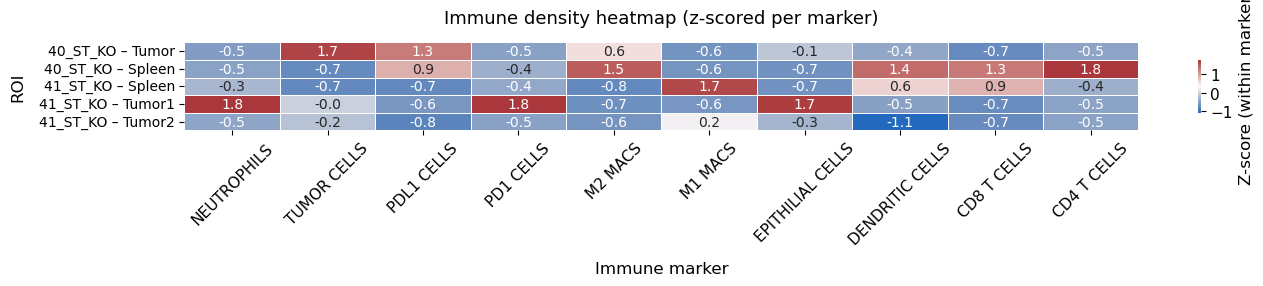

 Saved: immune_density_heatmap.png


<Figure size 640x480 with 0 Axes>

In [47]:
## Immune density heatmap (ROIs × markers)
# This is going to show a grid where each ROW is one ROI and each COLUMN is one
# immune marker -- color in each cell = density (cells/mm^2)
# Lets us see patterns across markers simultaneously:
# 
# With one sample, rows = all the ROIs in that one sample
# When more samples are added, all their ROIs stack as new rows automatically


# Build the matrix -- we want the shape to be (num of ROIs) × (num of markers)
# Use the ROI column as row labels so you know which row is which

heatmap_data = df[DENSITY_COLS].copy()

# Row labels are "SampleID – ROI" so rows stay unique across samples (no confusion)

heatmap_data.index = df["Sample"].astype(str) + " – " + df["ROI"].astype(str)

# Clean up column names for display, so for example "cd8_cells_per_mm2" becomes "CD8"
heatmap_data.columns = [c.replace("_cells_per_mm2", "").upper() for c in heatmap_data.columns]

# Z-score normalize each column (marker)
# Each marker has a very different absolute density range, without normalization
# the color scale can get dominated by whichever marker has the highest raw numbers
#
# This z-scoring rescales each marker independently to mean=0, SD=1.
# So now the color reflects high/low RELATIVE to that marker's own avg



NORMALIZE = True  # ‼️UPDATE‼️ if you want raw densities (set = False)

if NORMALIZE:
    # Subtract each column's mean and divide by SD
    # fillna(0) handles the case where all values in a column might be identical (SD=0)
    heatmap_plot = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()
    heatmap_plot = heatmap_plot.fillna(0)
    colorbar_label = "Z-score (within marker)"
    cmap_choice = "vlag" # diverging: blue (low) --> white (avg) --> red (high)
                        
else:
    heatmap_plot = heatmap_data
    colorbar_label = "Cells per mm^2"
    cmap_choice = "YlOrRd"  # sequential: yellow --> orange --> red, good for raw counts

# Draw the heatmap 
n_rows, n_cols = heatmap_plot.shape

# Scale figure size with data dimensions so nothing gets squished
fig_height = max(3, n_rows * 0.6)  # pick the bigger value -- 3 inches, or the scaled by ROI value
fig_width  = max(5, n_cols * 1.4)  

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.heatmap(
    heatmap_plot,
    ax=ax,
    cmap=cmap_choice,
    linewidths=0.5, # thinner white lines between cells so each box is visible
    linecolor="white",
    annot=True, # write the actual value inside each cell
    fmt=".1f", # one decimal place 
    annot_kws={"size": 10},  # font size of in-cell numbers
    cbar_kws={
        "label": colorbar_label,
        "shrink": 0.6,  # colorbar doesn't span full figure height
    },
)

# Axis formatting 
ax.set_xlabel("Immune marker", labelpad=10) # leave some room/padding between the label and the tick marks
ax.set_ylabel("ROI", labelpad=10)

title = "Immune density heatmap (z-scored per marker)" if NORMALIZE else "Immune density heatmap (raw counts)"
ax.set_title(title, pad=14)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center") # horizontal alignment to the center
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()
# Save the image
try:
    filename = "immune_density_heatmap.png"
    plt.savefig(SAVE_DIR / filename, dpi=SAVE_DPI, bbox_inches="tight")
    print(f" Saved: {filename}")
except Exception as e:
    print(f"Could not save heatmap: {e}") # show error message
finally:
    plt.close(fig)


Processing sample: 40_ST_KO
        NEUTROPHILS  TUMOR CELLS  PDL1 CELLS  PD1 CELLS   M2 MACS   M1 MACS  \
ROI                                                                           
Tumor      0.000000     0.349717    0.086175   0.000000  0.392977  0.000041   
Spleen     0.000041     0.000598    0.030932   0.000008  0.295861  0.002000   

        EPITHILIAL CELLS  DENDRITIC CELLS  CD8 T CELLS  CD4 T CELLS  
ROI                                                                  
Tumor           0.024778         0.141377     0.000162     0.004773  
Spleen          0.000066         0.201271     0.041007     0.428215  

Correlation matrix for 40_ST_KO:
ROI     Tumor  Spleen
ROI                  
Tumor    1.00    0.24
Spleen   0.24    1.00


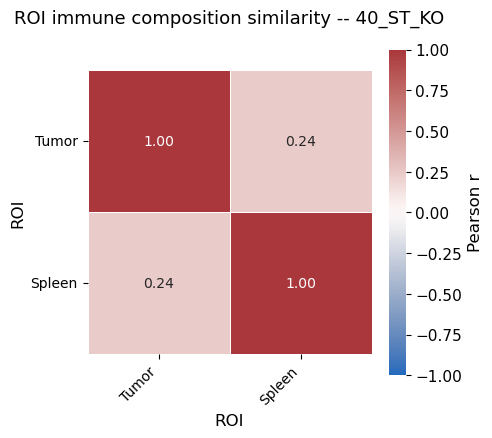

Saved: roi_similarity_heatmap_40_ST_KO.png

Processing sample: 41_ST_KO
        NEUTROPHILS  TUMOR CELLS  PDL1 CELLS  PD1 CELLS   M2 MACS   M1 MACS  \
ROI                                                                           
Spleen     0.000220     0.000186    0.001710   0.000004  0.003797  0.768499   
Tumor1     0.006325     0.147899    0.013687   0.000454  0.045941  0.037647   
Tumor2     0.000159     0.084219    0.001169   0.000000  0.044733  0.675896   

        EPITHILIAL CELLS  DENDRITIC CELLS  CD8 T CELLS  CD4 T CELLS  
ROI                                                                  
Spleen          0.000157         0.144517     0.032949     0.023307  
Tumor1          0.162378         0.186653     0.000338     0.001107  
Tumor2          0.017502         0.027972     0.000024     0.000192  

Correlation matrix for 41_ST_KO:
ROI     Spleen  Tumor1  Tumor2
ROI                           
Spleen    1.00   -0.02    0.97
Tumor1   -0.02    1.00   -0.02
Tumor2    0.97   -0.02  

<Figure size 640x480 with 0 Axes>

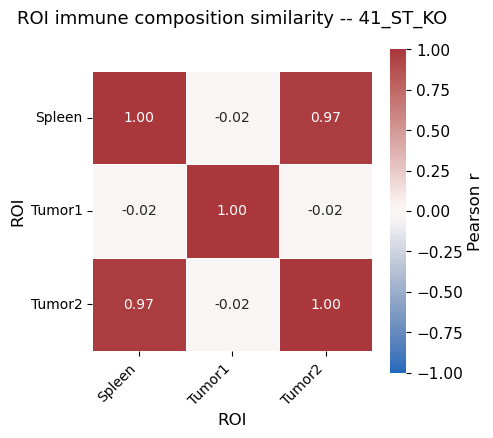

Saved: roi_similarity_heatmap_41_ST_KO.png

All ROI similarity heatmaps complete!


<Figure size 640x480 with 0 Axes>

In [52]:
## ROI similarity heatmap
# For each sample computes how similar each ROI's overall immune composition is to every other ROI
# Basically each ROI is represented as a vector of all cell type fractions 
# Correlation between 2 ROIs = how similar those vectors are
# Close to 1 = ROIs have similar immune composition (and then close to -1 = very dif)

for sample, sample_df in df.groupby("Sample"):  # loop through each sample separately
    
    print(f"\nProcessing sample: {sample}")
    
    # first build a matrix where rows = ROIs and columns = cell type fractions
    # rename column names so they're cleaner: "cd8 t cells_fraction" becomes "CD8 T CELLS"
    FRACTION_COLS = [c.replace('_cells_per_mm2', '_fraction') for c in DENSITY_COLS]
    cell_type_names = [c.replace('_cells_per_mm2', '').upper() for c in DENSITY_COLS]
    roi_matrix = sample_df.set_index("ROI")[FRACTION_COLS].copy() # make a copy of cell type fractions
    
    
    roi_matrix.columns = cell_type_names  # rename columns to clean names like "CD8 T CELLS"
    
    print(roi_matrix)  # print so you can see what's going into the correlation
    
    # Compute the ROI x ROI correlation matrix
    # .T transposes so ROIs become columns (which is what we need for the correlation to work)
    # because then .corr() correlates each pair of ROI columns
    # result is a square matrix -- so rows and columns are both ROI names
    corr_matrix = roi_matrix.T.corr()
    
    print(f"\nCorrelation matrix for {sample}:")
    print(corr_matrix.round(2)) # round to nearest 2 decimal places
    
    # Draw the heatmap
    fig, ax = plt.subplots(figsize=(max(5, len(corr_matrix) * 1.2), max(5, len(corr_matrix) * 1.0))) # scale by how many rois
    
    sns.heatmap(
        corr_matrix,
        ax=ax,
        cmap="vlag",   # blue = negative, white = zero, red = pos correlation
        vmin=-1, vmax=1,  # fix color scale to full correlation range
        annot=True,  # write the correlation value inside each cell
        fmt=".2f", # two decimal places
        annot_kws={"size": 10},
        linewidths=0.5,        
        linecolor="white",
        square=True,  # force square cells
        cbar_kws={"label": "Pearson r", "shrink": 0.8}, # using pearson correlation
    )
    
    ax.set_title(f"ROI immune composition similarity -- {sample}", pad=34)  # title with sample name and pad it so no overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)  # rotate x labels so they fit
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)  # keep y labels horizontal
    
    plt.tight_layout()  # auto adjust margins so nothing gets cut off
    plt.show()
    
    # Save with sample name in filename
    try:
        filename = f"roi_similarity_heatmap_{sample}.png"
        plt.savefig(SAVE_DIR / filename, dpi=SAVE_DPI, bbox_inches="tight")
        print(f"Saved: {filename}")
    except Exception as e:
        print(f"Could not save {sample}: {e}")
    finally:
        plt.close(fig)  # close figure 

print("\nAll ROI similarity heatmaps complete!")

Correlation matrix:
                  NEUTROPHILS  TUMOR CELLS  PDL1 CELLS  PD1 CELLS  M2 MACS  \
NEUTROPHILS              1.00        -0.08       -0.41       0.99    -0.44   
TUMOR CELLS             -0.08         1.00        0.56      -0.06     0.13   
PDL1 CELLS              -0.41         0.56        1.00      -0.33     0.88   
PD1 CELLS                0.99        -0.06       -0.33       1.00    -0.35   
M2 MACS                 -0.44         0.13        0.88      -0.35     1.00   
M1 MACS                 -0.25        -0.47       -0.61      -0.34    -0.58   
EPITHILIAL CELLS         0.95         0.19       -0.27       0.96    -0.39   
DENDRITIC CELLS         -0.26        -0.51        0.36      -0.23     0.61   
CD8 T CELLS             -0.36        -0.67        0.15      -0.35     0.46   
CD4 T CELLS             -0.29        -0.44        0.48      -0.22     0.83   

                  M1 MACS  EPITHILIAL CELLS  DENDRITIC CELLS  CD8 T CELLS  \
NEUTROPHILS         -0.25              0.95 

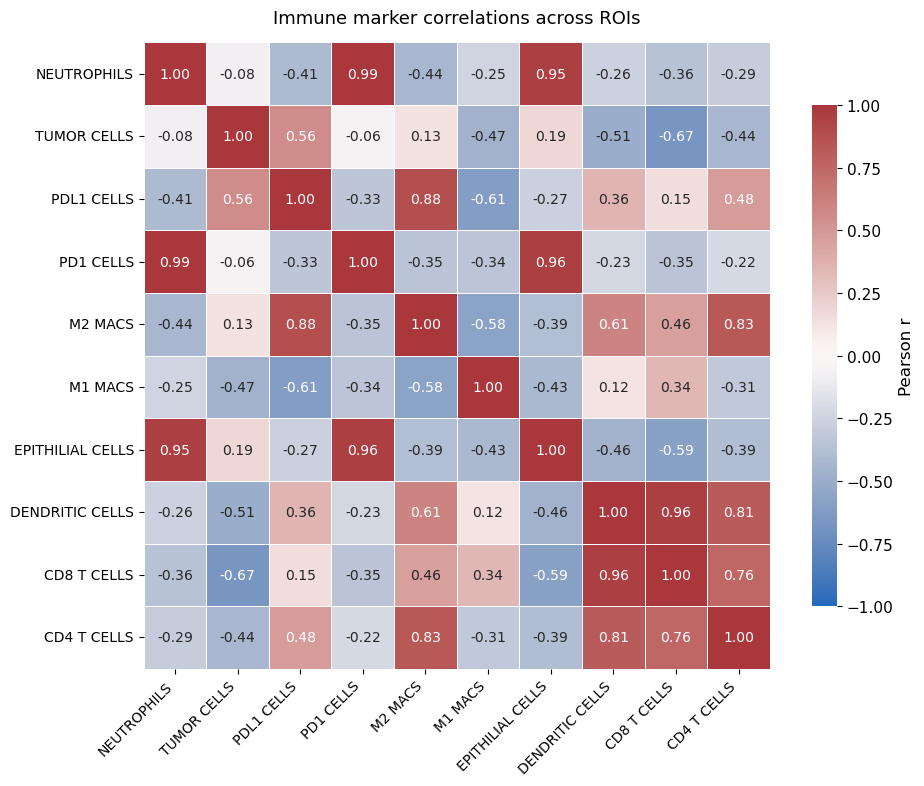

 Saved: immune_correlation_heatmap.png


<Figure size 640x480 with 0 Axes>

In [53]:
## Immune marker correlation heatmap
# Shows how correlated each pair of immune markers is across all ROIs
# Each cell = Pearson correlation coefficient between 2 markers calculated across all ROI density values.
# Correlation ranges from -1 to +1

# With only a few ROIs in one sample, the correlations will not seem statistically
# meaningful (need more ROIs/samples for this to be interpretable)
# But, the figure will become more informative as data grows



# Pull just the density columns, compute pairwise Pearson correlations
# .corr() does this automatically: for every pair of columns it computes
# the correlation across all rows (ROIs), giving a square matrix

corr_data = df[DENSITY_COLS].copy() # pull the density columns

# Clean up column names for display, "cd8_cells_per_mm2" becomes "CD8"
corr_data.columns = [ c.replace("_cells_per_mm2", "").upper() for c in corr_data.columns]


# This computes pairwise pearson correlations automatically, for every pair of columns it computes
# the correlation across all rows (ROIs)
# Result is a square matrix (df) -- rows and columns are both the marker names, each cell = Pearson r between marker i and j
corr_matrix = corr_data.corr(method="pearson")
                            

print("Correlation matrix:")
print(corr_matrix.round(2)) # round to 2 decimal places for readability

# Draw the heatmap 
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap="vlag", # diverging: blue (negative) to white (zero) to red (pos)
                          # same colormap as the density heatmap z scores
    vmin=-1, vmax=1, # fix the color scale to the full correlation range
    annot=True, # write the correlation value inside each cell
    fmt=".2f", # two decimal places 
    annot_kws={"size": 10},
    linewidths=0.5,# thin lines between cells
    linecolor="white",
    square=True,# force cells to be square
    cbar_kws={
        "label": "Pearson r",
        "shrink": 0.8,
    },
)

# Axis formatting 
ax.set_title("Immune marker correlations across ROIs", pad=14)

# Rotate x axis labels so they don't overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()
# Save 
try:
    filename = "immune_correlation_heatmap.png"
    plt.savefig(SAVE_DIR / filename, dpi=SAVE_DPI, bbox_inches="tight")
    print(f" Saved: {filename}")
except Exception as e:
    print(f"Could not save correlation heatmap: {e}")
finally:
    plt.close(fig)

All fraction columns found!


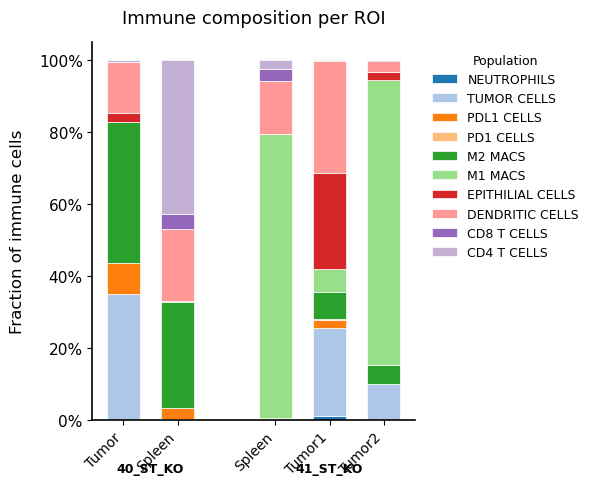

Saved: immune_composition_stacked_bar.png


<Figure size 640x480 with 0 Axes>

In [56]:
## Stacked bar chart of immune fractions per ROI
# With multiple samples, bars are grouped and labeled by sample


# Build the fraction table
FRACTION_COLS = [
    c.replace("_cells_per_mm2", "_fraction") for c in DENSITY_COLS
]

missing = [c for c in FRACTION_COLS if c not in df.columns]
if missing:
    print(f"Warning! Missing fraction columns: {missing}")
else:
    print("All fraction columns found!")

frac_data = df[FRACTION_COLS].copy() # make a copy (smaller df) of just those fraction columns

# Keep sample and ROI as separate columns for grouping logic below
frac_data["Sample"] = df["Sample"].astype(str)
frac_data["ROI"] = df["ROI"].astype(str)

# Clean up population column names: "cd8_fraction" becomes just "CD8"
pop_cols = [c.replace("_fraction", "").upper() for c in FRACTION_COLS]
frac_data.columns = pop_cols + ["Sample", "ROI"]

# Normalize each row to sum to exactly 1
frac_data[pop_cols] = frac_data[pop_cols].div(
    frac_data[pop_cols].sum(axis=1), axis=0) # first sum ACROSS all the columns for each row (ROI) producing one value per ORI
                                             # then take each ROI's row and divide every value in the row by that sum 

# Build x-axis positions with gaps between samples 
# Instead of evenly spaced bars 0,1,2..insert a gap of 0.5 between each sample group
# so bars within a sample are close together and samples look separated enough

GAP = 0.8  

x_positions = [] # x coordinate for each bar
x_tick_pos  = [] # x coordinate for each bar's tick label
x_tick_labels = [] # ROI name for each tick
sample_label_info = [] # for the sample bracket labels


# This loop helps figure out where to draw each bar on the x-axis while leaving a gap between sample groups
current_x = 0
for sample, group in frac_data.groupby("Sample", sort=False): # group the fraction df by sample, iterate through each sample group
    group_positions = []
    for _, row in group.iterrows(): # loops through each dataframe row (and its index) 
        x_positions.append(current_x) # add in the current x position 
        group_positions.append(current_x)
        x_tick_pos.append(current_x)
        x_tick_labels.append(row["ROI"])  # so just "ROI1" not "SAMPLE – ROI1"
        current_x += 1  # next bar is 1 unit to the right -- increase our x position counter by 1 and continue looping like this

    # Record the center of this sample group for the sample label below
    sample_center = (group_positions[0] + group_positions[-1]) / 2
    sample_label_info.append((sample_center, sample))

    current_x += GAP  # add the gap before the next sample group starts

# Colors 

default_colors = plt.cm.tab20.colors # the default tab20 pallette of 20 colors -- use to mark immune pops in our stacked bar
bar_colors = [
    default_colors[i % len(default_colors)] # build list of colors for each immune pop from the tab20 pallette
    for i, col in enumerate(pop_cols)       # the modulo ensures that if we have more than 20 markers, it will loop back to first color
]

# Draw the stacked bars manually 
fig_width  = max(5, len(x_positions) * 0.9 + len(sample_label_info) * GAP) #0.9 inches per bar, add in extra width for the gaps
fig_height = 5  # a little taller to leave room for sample labels below

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

bottoms = np.zeros(len(x_positions)) # tracks how tall the stack is so far for each bar

for i, pop in enumerate(pop_cols):
    heights = frac_data[pop].values  # fraction for this population, one value per ROI
    ax.bar(
        x_positions,
        heights,
        bottom=bottoms, # start drawing from the top of the previous population (however tall the existing bar is)
        color=bar_colors[i],
        width=0.6,
        edgecolor="white",
        linewidth=0.5,
        label=pop, # for the legend
    )
    bottoms += heights # move the floor up for the next population

# ROI tick labels
ax.set_xticks(x_tick_pos)
ax.set_xticklabels(x_tick_labels, rotation=45, ha="right", fontsize=10)

# Sample group labels below the ROI labels 
# Drawn as text just below the x axis using axis fraction coords
# ax.transData converts data x coords; we use a fixed y in axis fraction space
for center_x, sample_name in sample_label_info:
    ax.annotate(
        sample_name,
        xy=(center_x, 0), # data x coordinate
        xycoords=("data", "axes fraction"),  # x is in the same units as actual bar positions, y in axis fraction (0=bottom, 1=top)
        xytext=(0, -38), # offset downward in points
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="black",
    )

# Axis formatting 
ax.set_ylabel("Fraction of immune cells", labelpad=10)
ax.set_title("Immune composition per ROI", pad=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}")) #formats y axis tick labels as percentages instead of decimals

ax.legend(
    title="Population",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=9,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
# Save 
try:
    filename = "immune_composition_stacked_bar.png"
    plt.savefig(SAVE_DIR / filename, dpi=SAVE_DPI, bbox_inches="tight")
    print(f"Saved: {filename}")
except Exception as e:
    print(f"Could not save stacked bar: {e}")
finally:
    plt.close(fig)